<a href="https://colab.research.google.com/github/HS-base/FYP/blob/main/Belnd_Properties_VS_Mass_Fraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Belnd Properties Against Mass Fraction:

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Propane                                             

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (1.1702e+03 * pow(Y, 4)) + (-2.4681e+03 * pow(Y, 3)) + (1.7676e+03 * pow(Y, 2)) + (-4.6842e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (1.4350e+06 * pow(Y, 3)) + (-2.1460e+06 * pow(Y, 2)) + (-1.2954e+05 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (-1.1159e+03 * pow(Y, 3)) + (2.5046e+03 * pow(Y, 2)) + (-3.4446e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (-3.4653e+02 * pow(Y, 3)) + (9.1914e+02 * pow(Y, 2)) + (-1.6632e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (9.5463e+02 * pow(Y, 4)) + (-1.9507e+03 * pow(Y, 3)) + (1.3703e+03 * pow(Y, 2)) + (-3.7013e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (1.1349e+06 * pow(Y, 3)) + (-1.6572e+06 * pow(Y, 2)) + (-2.9441e+05 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (-1.0232e+03 * pow(Y, 3)) + (2.4608e+03 * pow(Y, 

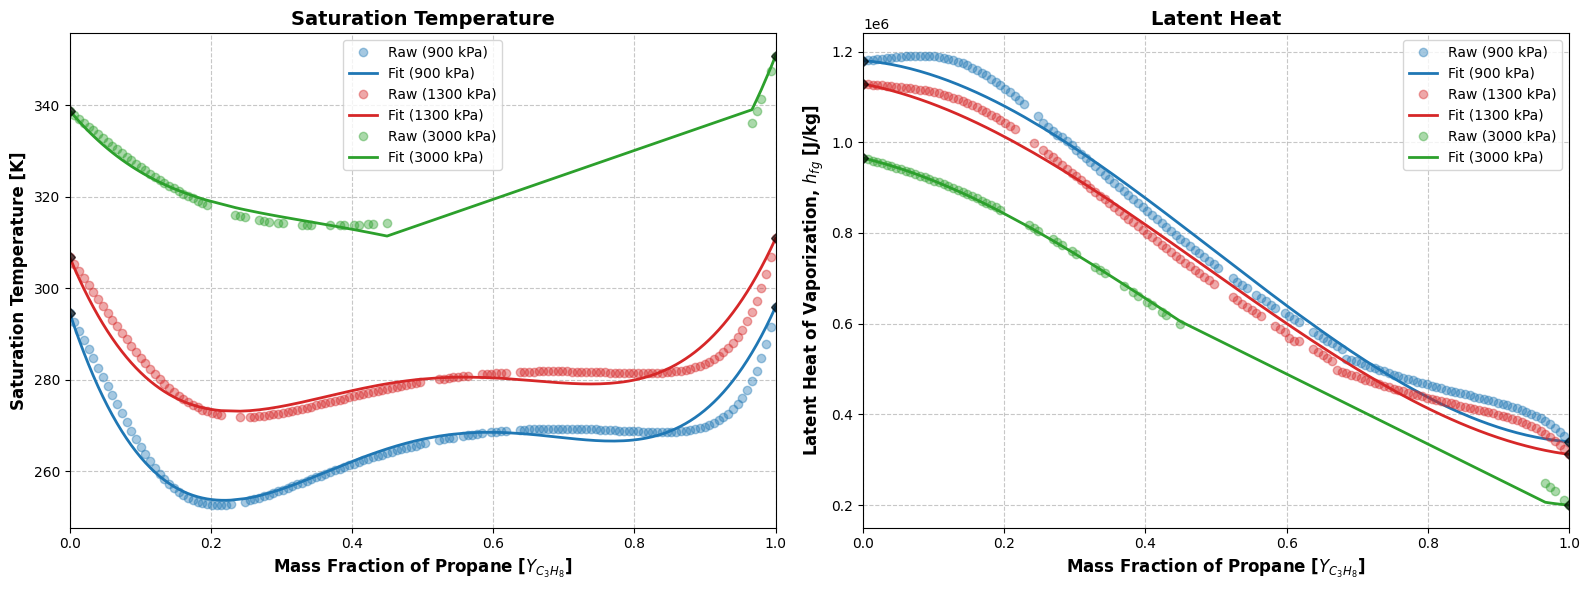

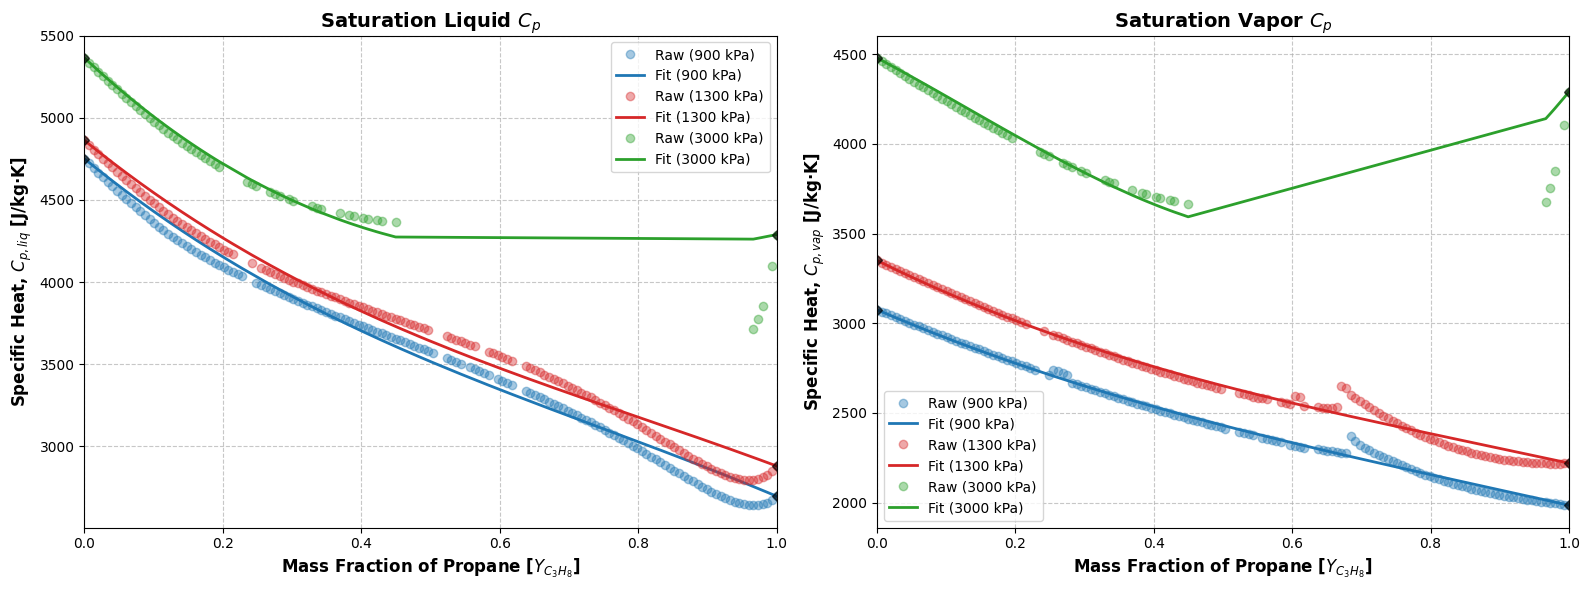

In [ ]:
# @title
def plot_properties_and_generate_udf_eqs():
    # Updated to Propane & Ammonia
    fluid_string = "Propane&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Propane MASS fractions from 0 to 1
    y_propane_array = np.linspace(0, 1.0, 150)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Propane                                             ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_propane_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Benzene                                             

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (2.5934e+03 * pow(Y, 4)) + (-4.2617e+03 * pow(Y, 3)) + (2.1096e+03 * pow(Y, 2)) + (-2.9031e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-1.3176e+06 * pow(Y, 3)) + (1.3517e+06 * pow(Y, 2)) + (-9.0000e+05 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (4.0067e+03 * pow(Y, 3)) + (-4.4643e+03 * pow(Y, 2)) + (-2.0215e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (-1.6982e+03 * pow(Y, 3)) + (4.4692e+03 * pow(Y, 2)) + (-4.0523e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (2.6143e+03 * pow(Y, 4)) + (-4.2788e+03 * pow(Y, 3)) + (2.1139e+03 * pow(Y, 2)) + (-2.8936e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-1.4664e+06 * pow(Y, 3)) + (1.5341e+06 * pow(Y, 2)) + (-9.0532e+05 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (4.4625e+03 * pow(Y, 3)) + (-4.9836e+03 * pow(Y, 

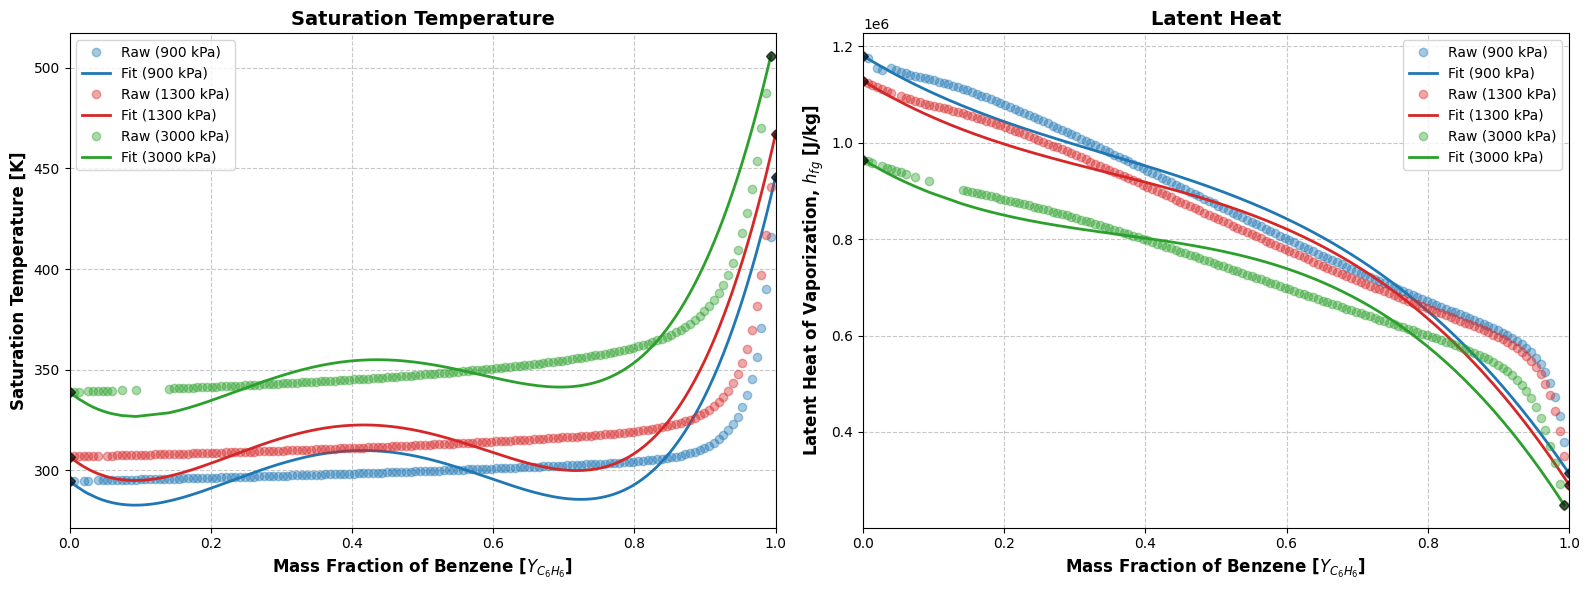

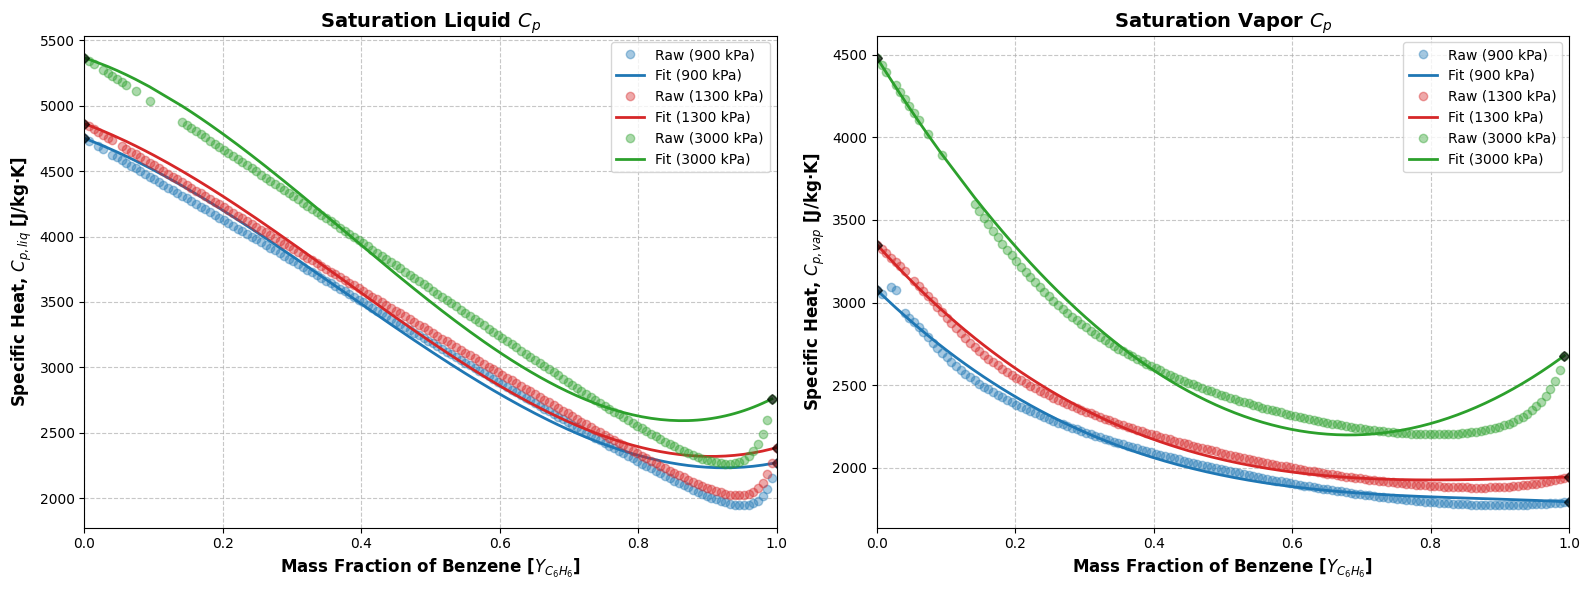

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to Benzene & Ammonia
    fluid_string = "Benzene&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Benzene MASS fractions from 0 to 1
    y_benzene_array = np.linspace(0, 1.0, 150)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Benzene                                             ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_benzene_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Benzene [$Y_{C_6H_6}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Benzene [$Y_{C_6H_6}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Benzene [$Y_{C_6H_6}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Benzene [$Y_{C_6H_6}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Butane                                              

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (1.3179e+03 * pow(Y, 4)) + (-2.2324e+03 * pow(Y, 3)) + (1.1650e+03 * pow(Y, 2)) + (-1.9738e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-6.9203e+05 * pow(Y, 3)) + (1.1582e+06 * pow(Y, 2)) + (-1.3453e+06 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (2.4552e+03 * pow(Y, 3)) + (-2.8349e+03 * pow(Y, 2)) + (-1.5725e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (2.1381e+03 * pow(Y, 3)) + (-2.5875e+03 * pow(Y, 2)) + (-4.0062e+02 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (1.3401e+03 * pow(Y, 4)) + (-2.2400e+03 * pow(Y, 3)) + (1.1404e+03 * pow(Y, 2)) + (-1.8230e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-8.2458e+05 * pow(Y, 3)) + (1.3518e+06 * pow(Y, 2)) + (-1.3825e+06 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (3.1135e+03 * pow(Y, 3)) + (-3.7191e+03 * pow(Y, 

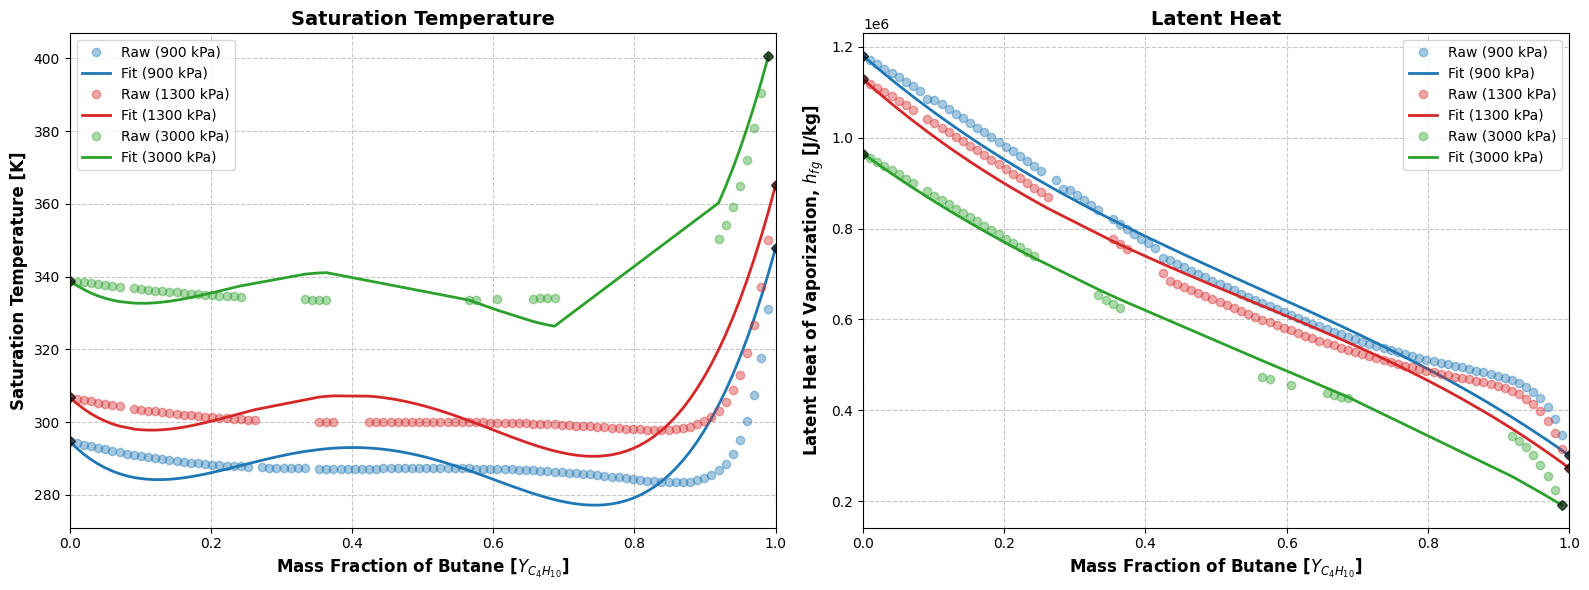

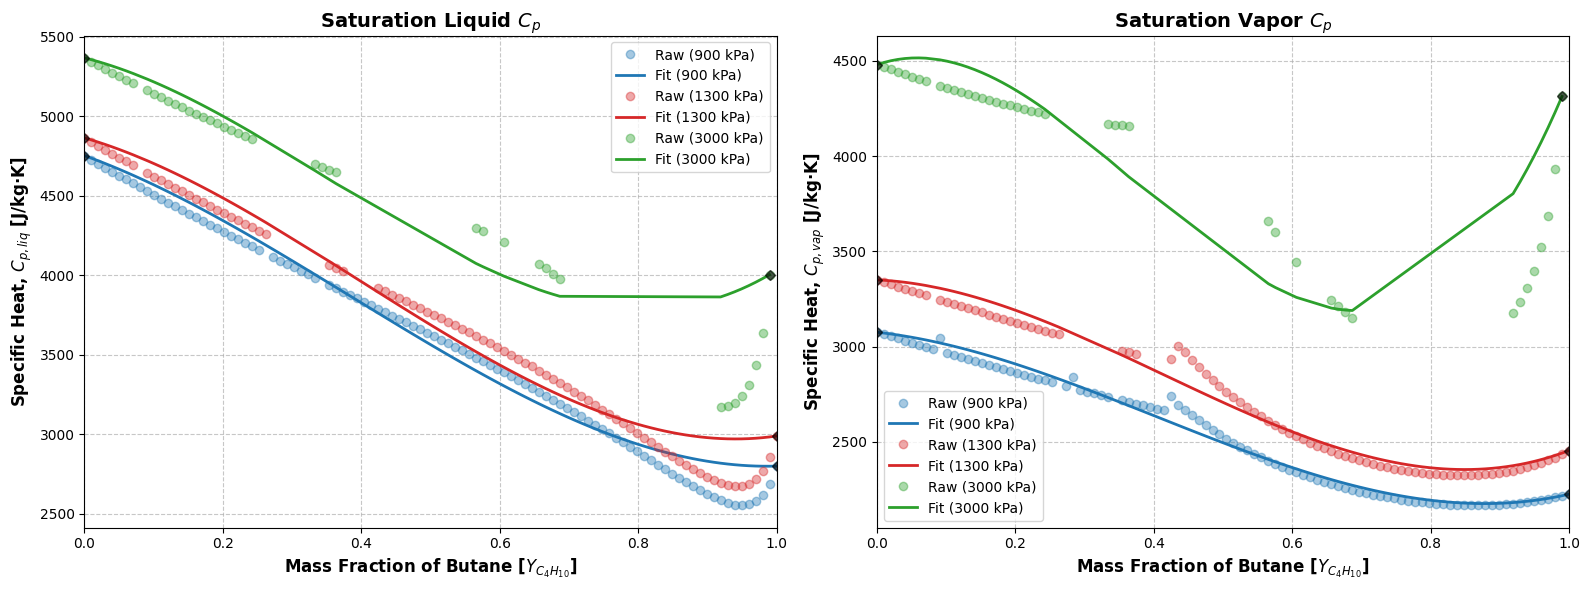

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to Butane & Ammonia
    fluid_string = "Butane&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Butane MASS fractions from 0 to 1
    y_butane_array = np.linspace(0, 1.0, 100)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Butane                                              ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_butane_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Pentane                                             

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (2.0621e+03 * pow(Y, 4)) + (-3.4312e+03 * pow(Y, 3)) + (1.7146e+03 * pow(Y, 2)) + (-2.4741e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-1.7292e+06 * pow(Y, 3)) + (2.4204e+06 * pow(Y, 2)) + (-1.5994e+06 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (4.4025e+03 * pow(Y, 3)) + (-5.3005e+03 * pow(Y, 2)) + (-9.5904e+02 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (2.1484e+03 * pow(Y, 3)) + (-1.7823e+03 * pow(Y, 2)) + (-1.0618e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (2.0540e+03 * pow(Y, 4)) + (-3.3976e+03 * pow(Y, 3)) + (1.6908e+03 * pow(Y, 2)) + (-2.4223e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-1.8834e+06 * pow(Y, 3)) + (2.6248e+06 * pow(Y, 2)) + (-1.6264e+06 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (5.2766e+03 * pow(Y, 3)) + (-6.3958e+03 * pow(Y, 

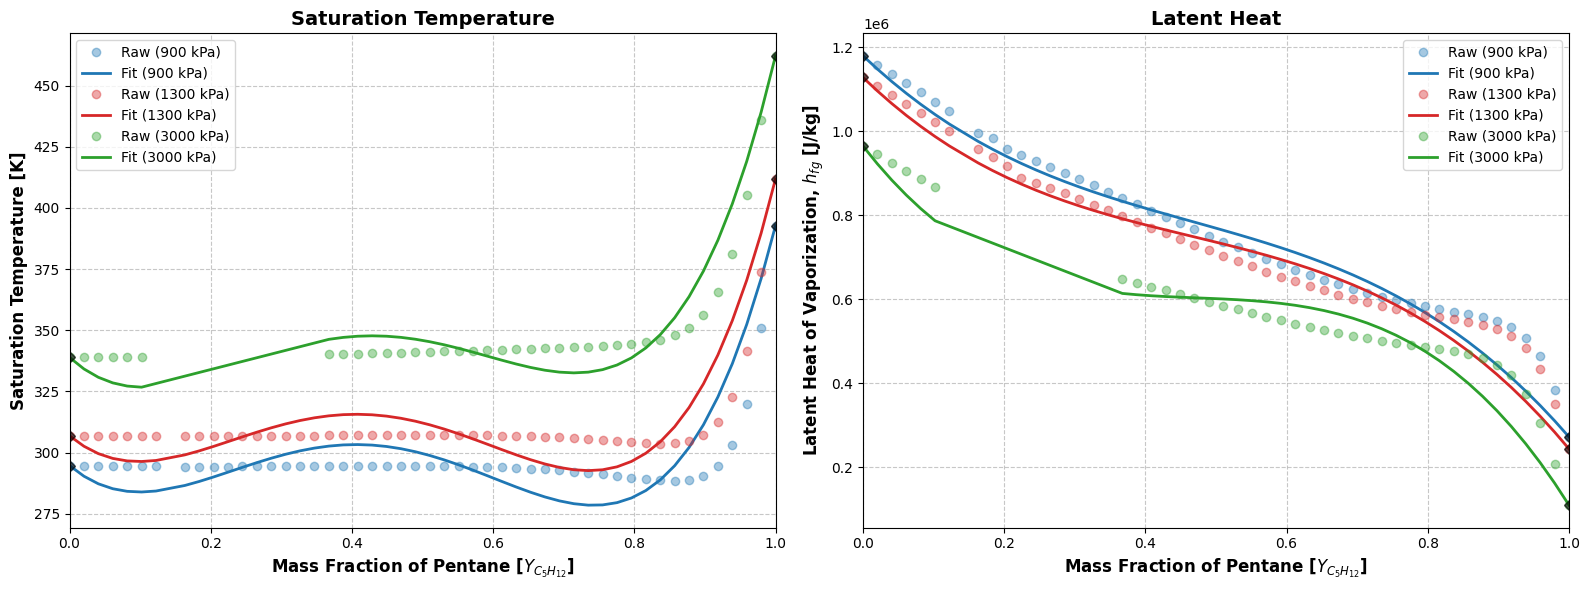

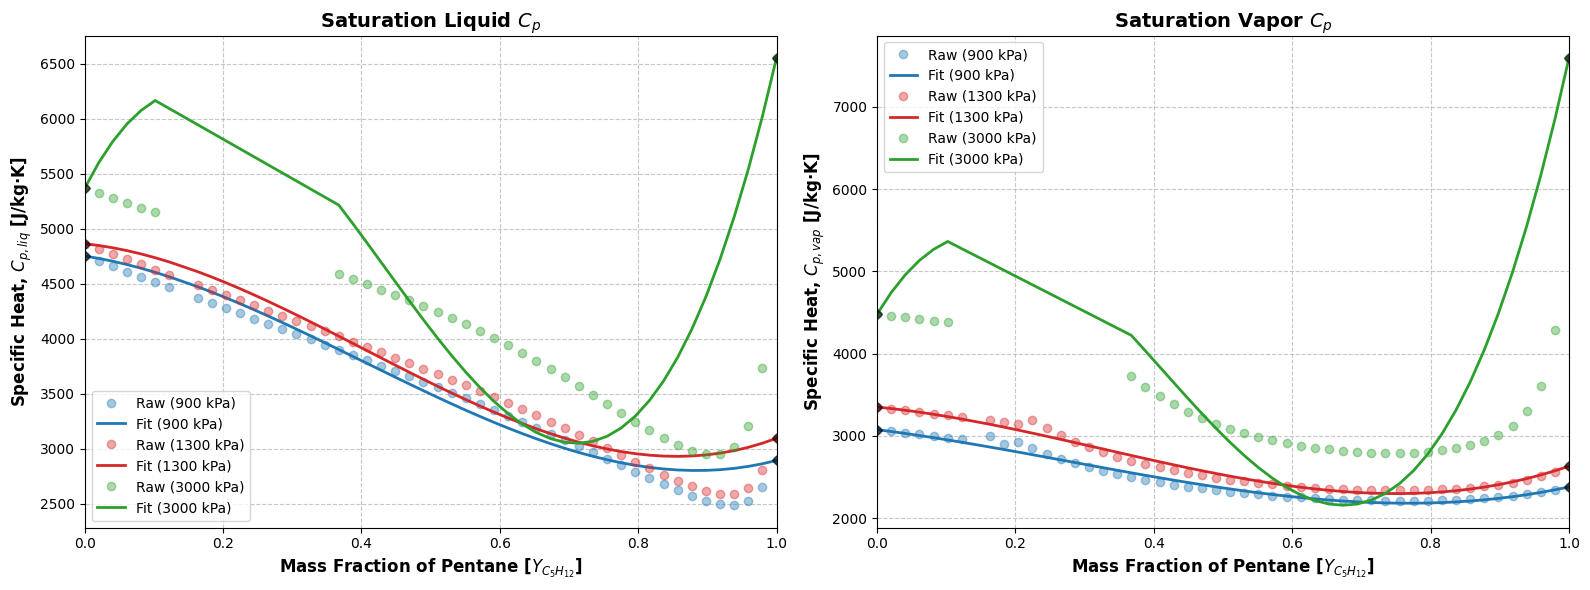

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to Pentane & Ammonia
    fluid_string = "Pentane&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Pentane MASS fractions from 0 to 1
    y_pentane_array = np.linspace(0, 1.0, 50)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Pentane                                             ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_pentane_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Pentane [$Y_{C_5H_{12}}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Pentane [$Y_{C_5H_{12}}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Pentane [$Y_{C_5H_{12}}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Pentane [$Y_{C_5H_{12}}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Hexane                                              

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (2.8993e+03 * pow(Y, 4)) + (-4.8263e+03 * pow(Y, 3)) + (2.4000e+03 * pow(Y, 2)) + (-3.3525e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-2.1103e+06 * pow(Y, 3)) + (2.6392e+06 * pow(Y, 2)) + (-1.4609e+06 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (5.7763e+03 * pow(Y, 3)) + (-6.8274e+03 * pow(Y, 2)) + (-6.6902e+02 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (3.5096e+02 * pow(Y, 3)) + (1.6448e+03 * pow(Y, 2)) + (-2.5012e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (3.0261e+03 * pow(Y, 4)) + (-5.0727e+03 * pow(Y, 3)) + (2.5598e+03 * pow(Y, 2)) + (-3.6702e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-2.3694e+06 * pow(Y, 3)) + (2.9882e+06 * pow(Y, 2)) + (-1.5284e+06 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (6.9630e+03 * pow(Y, 3)) + (-8.3138e+03 * pow(Y, 2

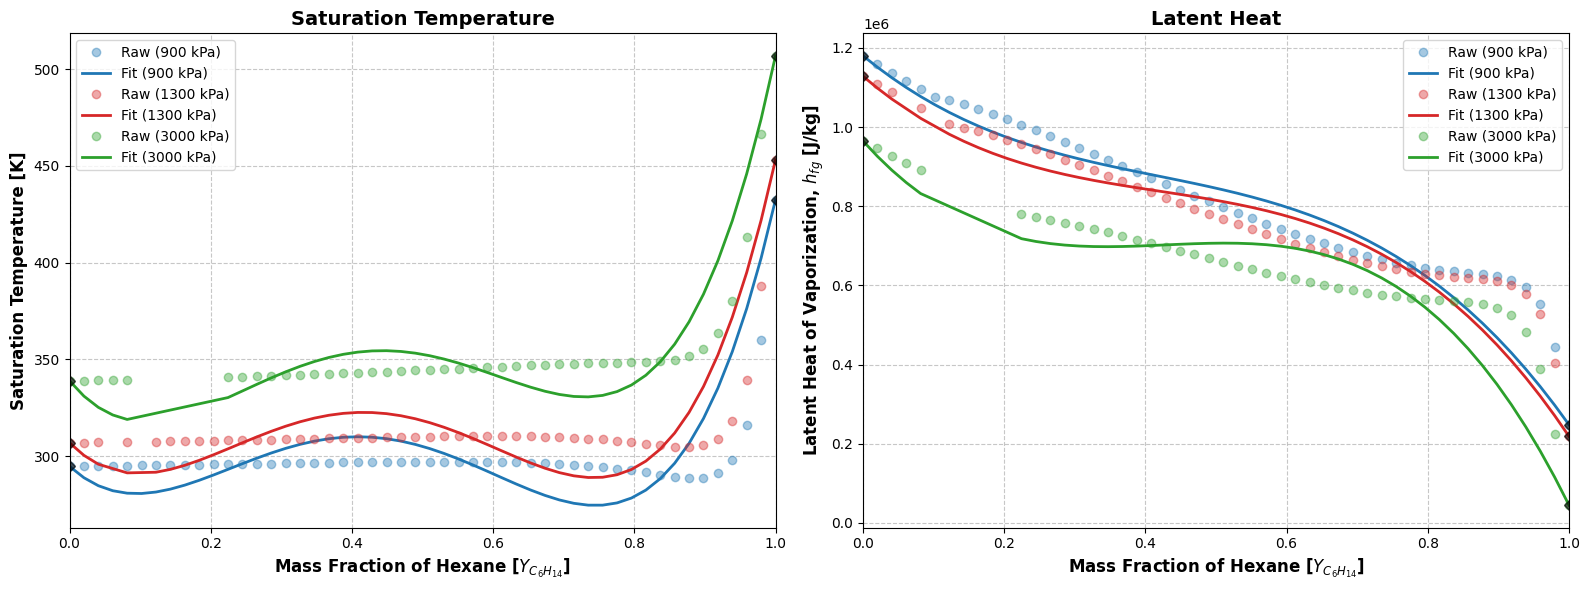

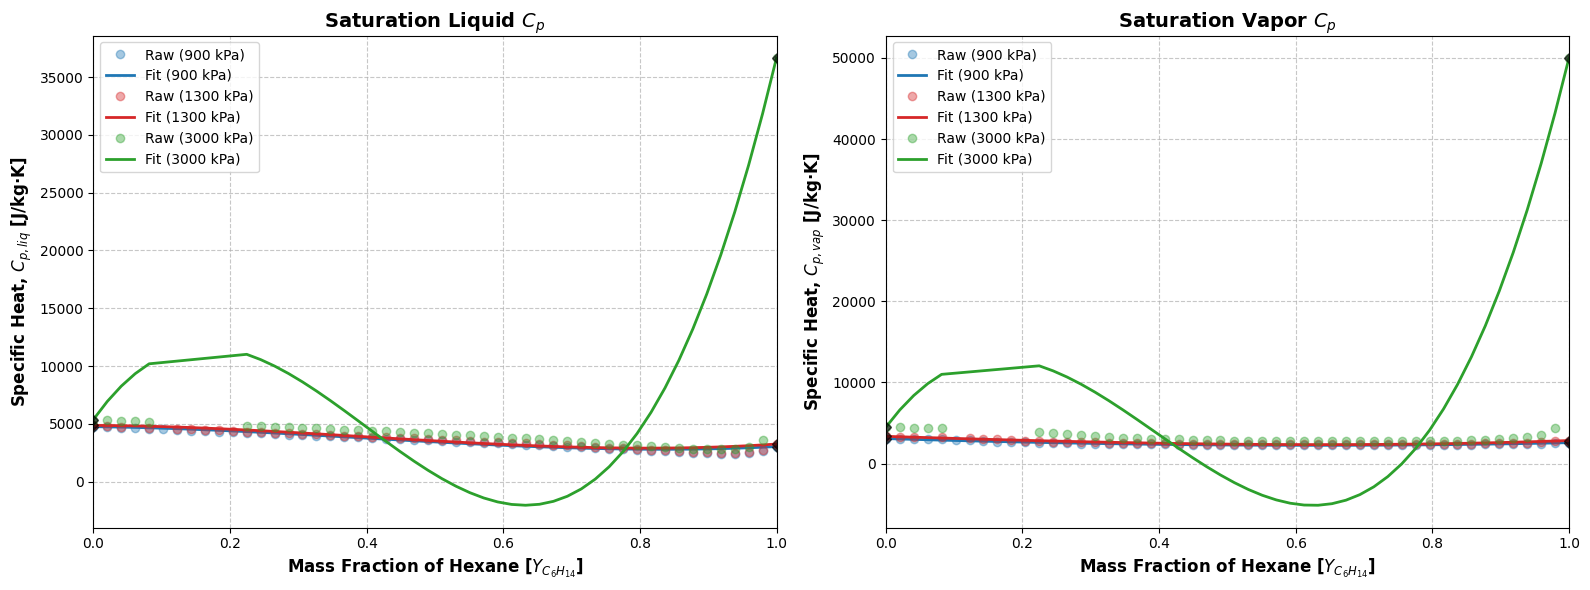

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def constrained_4th_deg_fit(x_data, y_data):
    """
    Forces a 4th-degree polynomial to pass exactly through the first and last points.
    Returns standard coefficients [c4, c3, c2, c1, c0] for c4*x^4 + c3*x^3 + c2*x^2 + c1*x + c0
    """
    x0, y0 = x_data[0], y_data[0]
    xN, yN = x_data[-1], y_data[-1]

    # 1. Linear baseline: y = mx + k
    m = (yN - y0) / (xN - x0)
    k = y0 - m * x0
    g_x = m * x_data + k

    # 2. Residuals (the difference between the actual data and the linear baseline)
    residual = y_data - g_x

    # 3. Forcing factor that guarantees 0 at the extremes: F(x) = (x - x0)(x - xN)
    factor = (x_data - x0) * (x_data - xN)

    # 4. Least squares fitting for the remaining degrees of freedom
    # To get a 4th-degree overall polynomial, multiply the degree-2 factor
    # by a degree-2 polynomial: Q(x) = A*x^2 + B*x + C
    X_features = np.column_stack((factor * (x_data**2), factor * x_data, factor))

    # Use rcond=None to avoid FutureWarnings in newer numpy versions
    coeffs, _, _, _ = np.linalg.lstsq(X_features, residual, rcond=None)
    A, B, C = coeffs[0], coeffs[1], coeffs[2]

    # 5. Expand to standard degree-4 coefficients
    # P(x) = (A*x^2 + B*x + C)(x^2 - S*x + P_val) + m*x + k
    S = x0 + xN
    P_val = x0 * xN

    c4 = A
    c3 = B - S * A
    c2 = C - S * B + P_val * A
    c1 = P_val * B - S * C + m
    c0 = P_val * C + k

    return [c4, c3, c2, c1, c0]

def plot_properties_and_generate_udf_eqs():
    # Updated to Hexane & Ammonia
    fluid_string = "Hexane&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Hexane MASS fractions from 0 to 1
    y_hexane_array = np.linspace(0, 1.0, 50)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Hexane                                              ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_hexane_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Hexane [$Y_{C_6H_{14}}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Hexane [$Y_{C_6H_{14}}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Hexane [$Y_{C_6H_{14}}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Hexane [$Y_{C_6H_{14}}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of m-Xylene                                            

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (4.3293e+03 * pow(Y, 4)) + (-7.1925e+03 * pow(Y, 3)) + (3.5903e+03 * pow(Y, 2)) + (-5.0435e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-1.7713e+06 * pow(Y, 3)) + (1.4009e+06 * pow(Y, 2)) + (-5.5007e+05 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (6.4307e+03 * pow(Y, 3)) + (-7.2858e+03 * pow(Y, 2)) + (-1.3035e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (-3.0319e+03 * pow(Y, 3)) + (7.0287e+03 * pow(Y, 2)) + (-4.8996e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (4.4239e+03 * pow(Y, 4)) + (-7.3340e+03 * pow(Y, 3)) + (3.6567e+03 * pow(Y, 2)) + (-5.1225e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-2.0035e+06 * pow(Y, 3)) + (1.6702e+06 * pow(Y, 2)) + (-5.6200e+05 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (7.1797e+03 * pow(Y, 3)) + (-8.1292e+03 * pow(Y, 

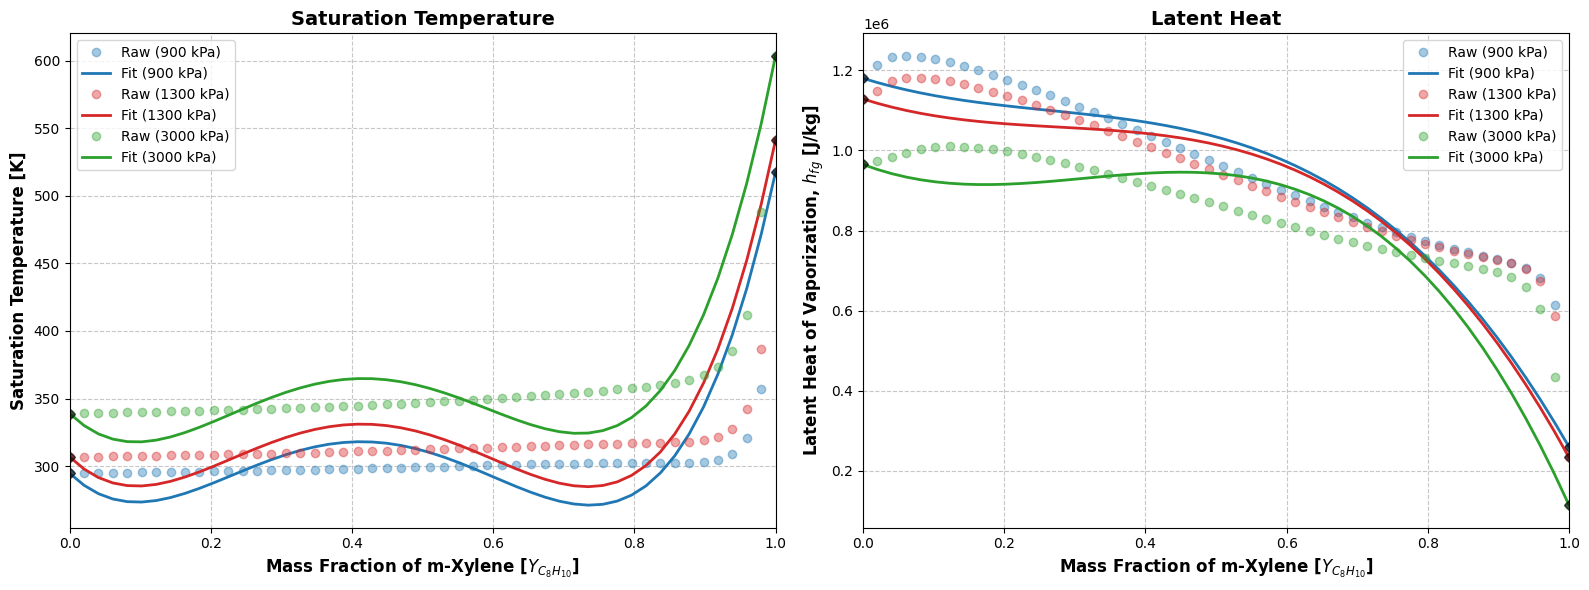

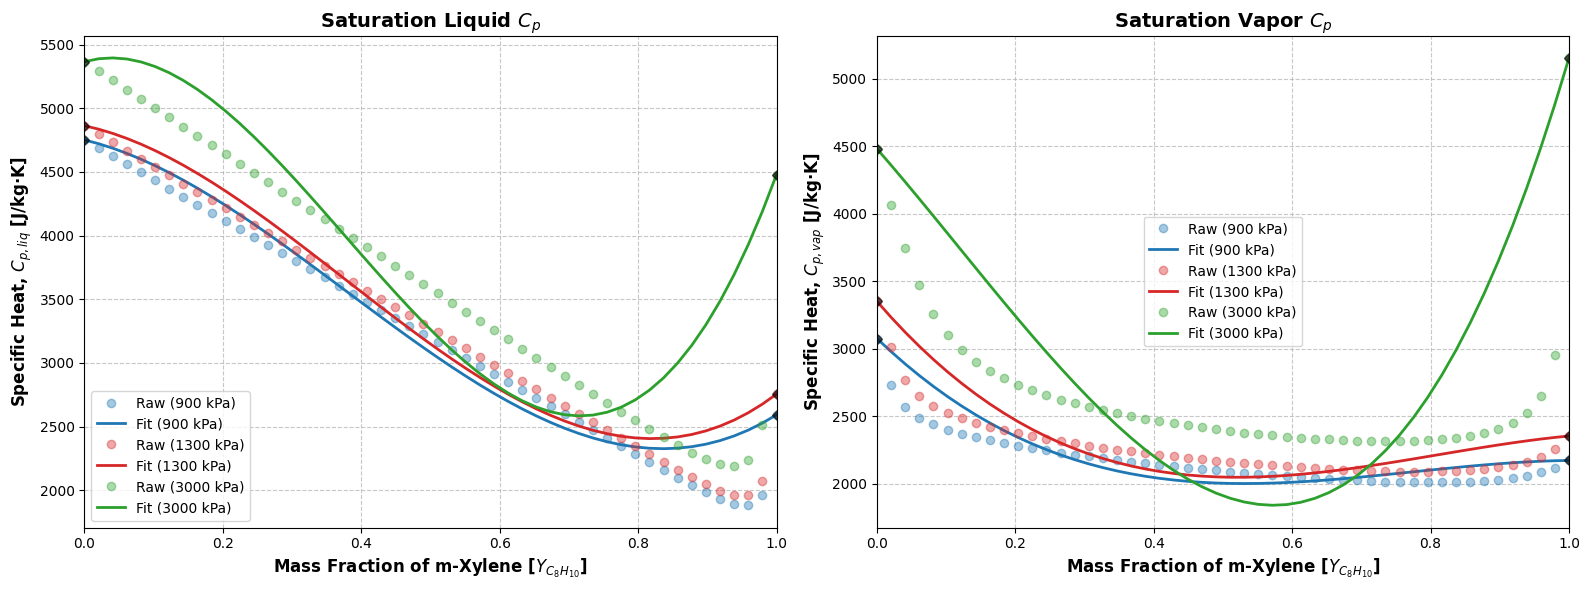

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to m-Xylene & Ammonia
    fluid_string = "m-Xylene&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of m-Xylene MASS fractions from 0 to 1
    y_mxylene_array = np.linspace(0, 1.0, 50)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of m-Xylene                                            ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_mxylene_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of m-Xylene [$Y_{C_8H_{10}}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of m-Xylene [$Y_{C_8H_{10}}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of m-Xylene [$Y_{C_8H_{10}}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of m-Xylene [$Y_{C_8H_{10}}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Propylene                                           

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (3.9464e+02 * pow(Y, 4)) + (-8.0120e+02 * pow(Y, 3)) + (5.8444e+02 * pow(Y, 2)) + (-1.8409e+02 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (7.2338e+05 * pow(Y, 3)) + (-9.8797e+05 * pow(Y, 2)) + (-5.6287e+05 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (-5.2994e+02 * pow(Y, 3)) + (1.2282e+03 * pow(Y, 2)) + (-2.8813e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (-7.0270e+02 * pow(Y, 3)) + (1.1732e+03 * pow(Y, 2)) + (-1.7079e+03 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (3.6316e+02 * pow(Y, 4)) + (-7.0577e+02 * pow(Y, 3)) + (4.9666e+02 * pow(Y, 2)) + (-1.5789e+02 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (6.2019e+05 * pow(Y, 3)) + (-8.1292e+05 * pow(Y, 2)) + (-6.1037e+05 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (-5.3937e+02 * pow(Y, 3)) + (1.2980e+03 * pow(Y, 

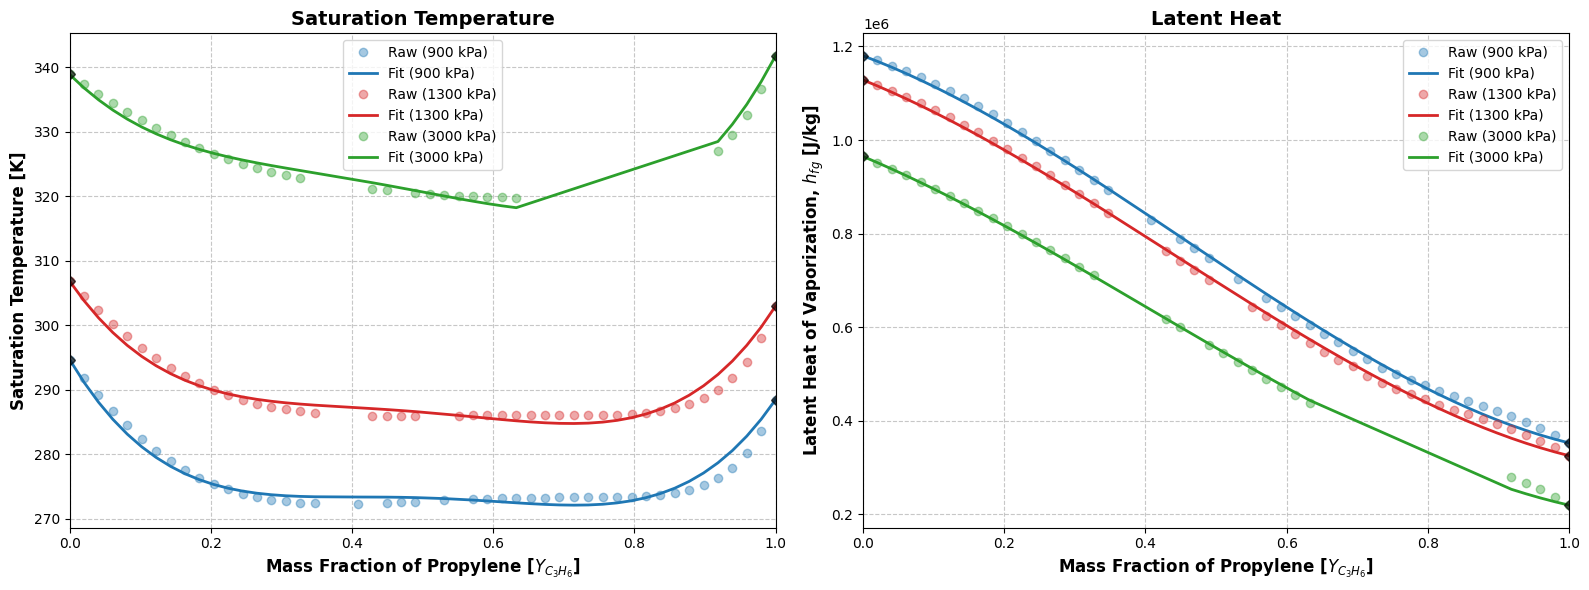

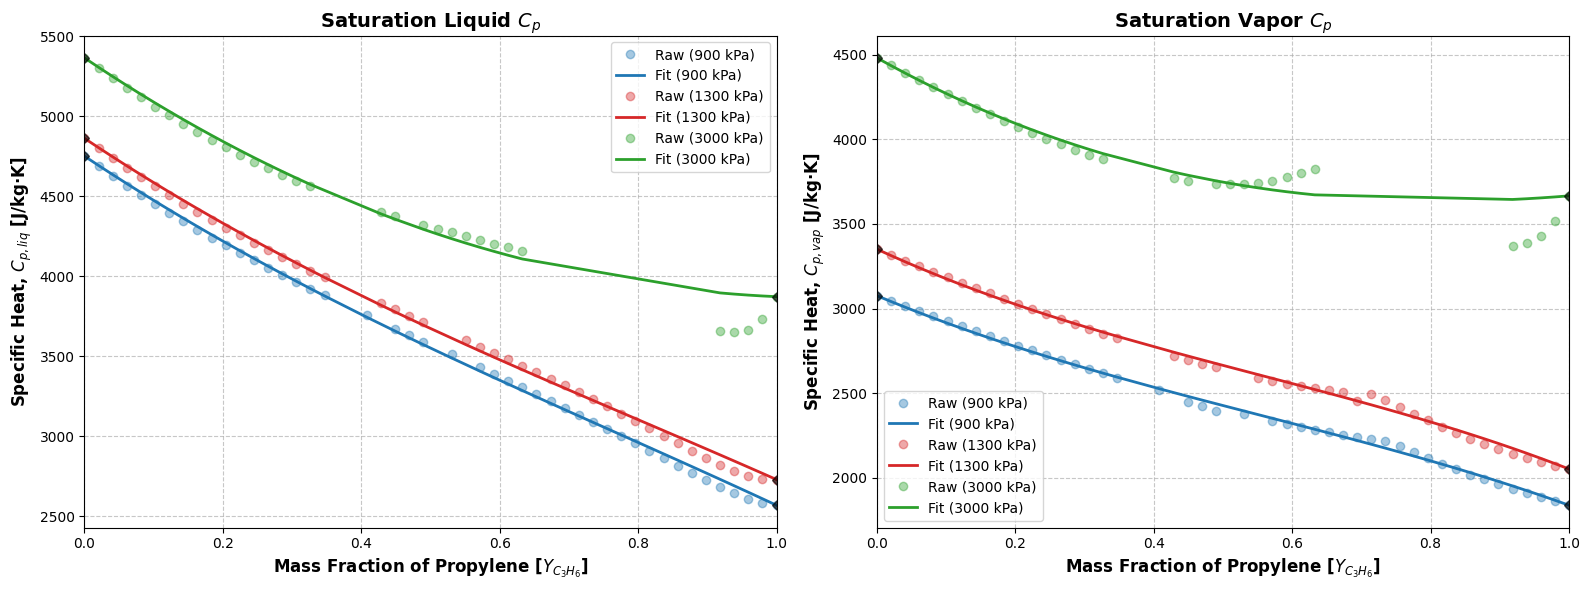

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to Propylene & Ammonia
    fluid_string = "Propylene&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Propylene MASS fractions from 0 to 1
    y_propylene_array = np.linspace(0, 1.0, 50)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Propylene                                           ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_propylene_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()

 ANSYS Fluent UDF Equations: Polynomial Fits                              
 Y = Mass Fraction of Propyne                                             

--- 900 kPa Operating Pressure ---
  T_sat (K)         = (1.3629e+02 * pow(Y, 4)) + (-1.9823e+02 * pow(Y, 3)) + (9.7782e+01 * pow(Y, 2)) + (-1.6525e+01 * Y) + (2.9469e+02)
  H_fg (J/kg)       = (-5.2435e+04 * pow(Y, 3)) + (1.7850e+05 * pow(Y, 2)) + (-8.6386e+05 * Y) + 1.1801e+06
  Cp_liq (J/kg-K)   = (5.6082e+02 * pow(Y, 3)) + (-6.1174e+02 * pow(Y, 2)) + (-2.2051e+03 * Y) + 4.7511e+03
  Cp_vap (J/kg-K)   = (3.6796e+02 * pow(Y, 3)) + (-5.4600e+02 * pow(Y, 2)) + (-8.8296e+02 * Y) + 3.0757e+03

--- 1300 kPa Operating Pressure ---
  T_sat (K)         = (1.3855e+02 * pow(Y, 4)) + (-1.9852e+02 * pow(Y, 3)) + (9.7283e+01 * pow(Y, 2)) + (-1.5421e+01 * Y) + (3.0684e+02)
  H_fg (J/kg)       = (-7.0782e+04 * pow(Y, 3)) + (2.0092e+05 * pow(Y, 2)) + (-8.4300e+05 * Y) + 1.1284e+06
  Cp_liq (J/kg-K)   = (6.8348e+02 * pow(Y, 3)) + (-6.8329e+02 * pow(Y, 

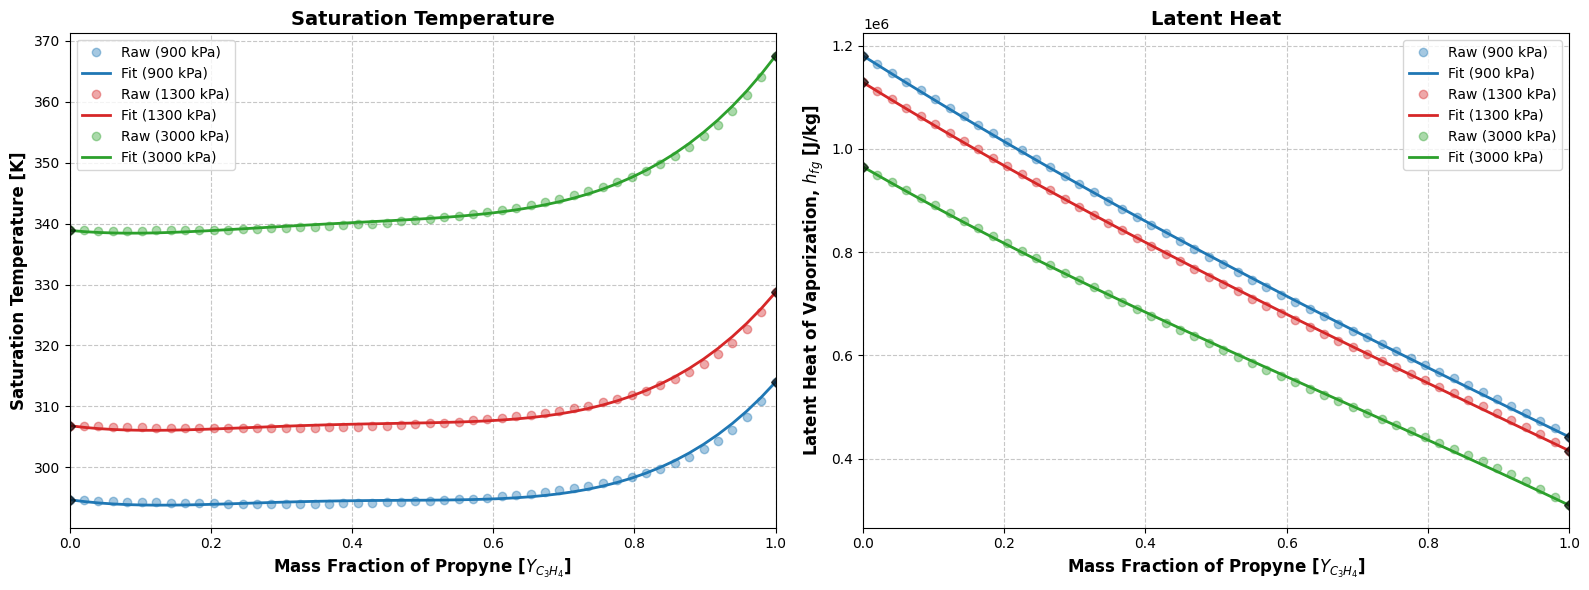

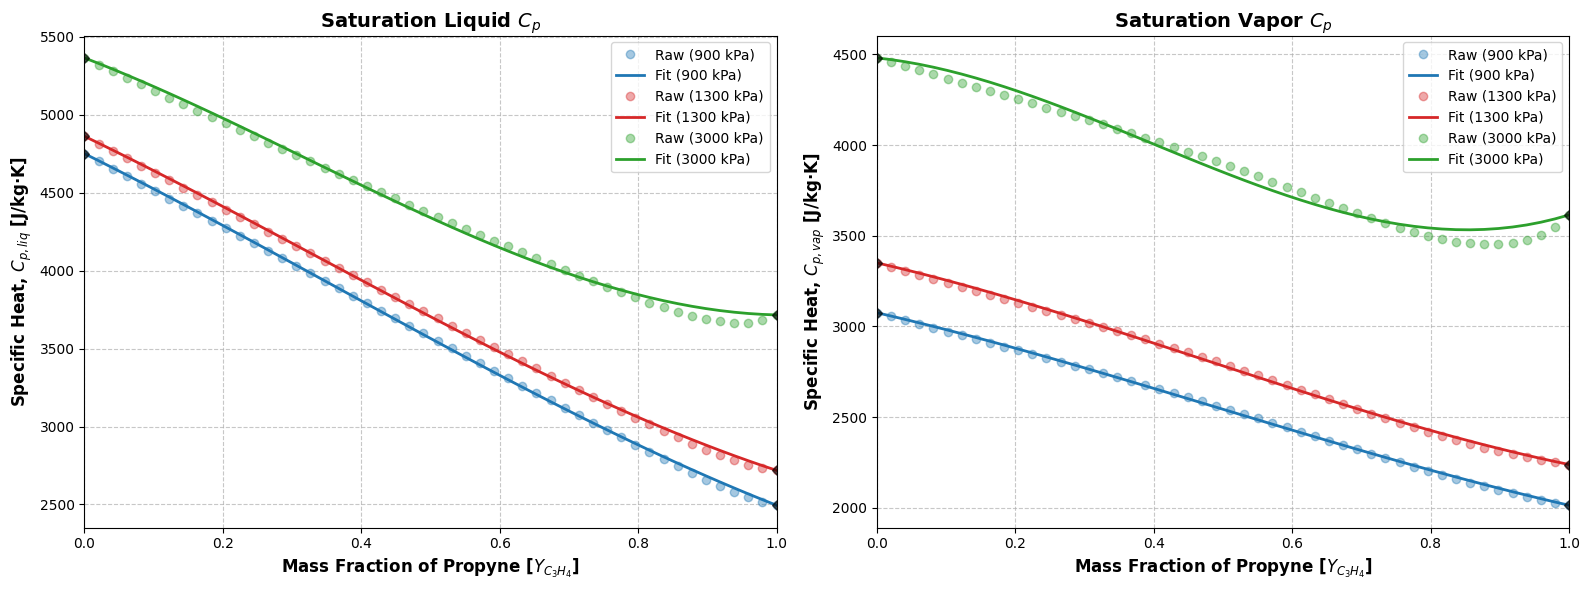

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_properties_and_generate_udf_eqs():
    # Updated to Propyne & Ammonia
    fluid_string = "Propyne&Ammonia"
    AS = CP.AbstractState("HEOS", fluid_string)

    # Define the pressures to evaluate (in kPa)
    pressures_kPa = [900, 1300, 3000]

    # Generate an array of Propyne MASS fractions from 0 to 1
    y_propyne_array = np.linspace(0, 1.0, 50)
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # --- SETUP TWO FIGURES ---
    # Figure 1: Saturation Temp and Latent Heat
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Figure 2: Specific Heat (Liquid) and Specific Heat (Vapor)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    print("==========================================================================")
    print(" ANSYS Fluent UDF Equations: Polynomial Fits                              ")
    print(" Y = Mass Fraction of Propyne                                             ")
    print("==========================================================================\n")

    for i, P_kPa in enumerate(pressures_kPa):
        P_Pa = P_kPa * 1000.0

        valid_y = []
        T_bubble = []
        Hfg_mix = []
        Cp_mix_liq = []
        Cp_mix_vap = []

        # Calculate properties for each mass fraction
        for y0 in y_propyne_array:
            y1 = 1.0 - y0  # Ammonia MASS fraction
            AS.set_mass_fractions([y0, y1])

            try:
                # 1. Bubble point calculations (Liquid, Q=0)
                AS.update(CP.PQ_INPUTS, P_Pa, 0.0)
                t_bub = AS.T()
                cp_l = AS.cpmass()
                h_l = AS.hmass() # Enthalpy Liquid

                # 2. Dew point calculations (Vapor, Q=1)
                AS.update(CP.PQ_INPUTS, P_Pa, 1.0)
                cp_v = AS.cpmass()
                h_v = AS.hmass() # Enthalpy Vapor

                # Latent Heat of Evaporation
                h_fg = h_v - h_l

                # If all converge, append to arrays
                T_bubble.append(t_bub)
                Hfg_mix.append(h_fg)
                Cp_mix_liq.append(cp_l)
                Cp_mix_vap.append(cp_v)
                valid_y.append(y0)

            except ValueError:
                # Skip points where the HEOS engine fails to converge
                pass

        x_data = np.array(valid_y)
        t_data = np.array(T_bubble)
        hfg_data = np.array(Hfg_mix)
        cp_liq_data = np.array(Cp_mix_liq)
        cp_vap_data = np.array(Cp_mix_vap)

        if len(x_data) > 4:
            # Generate the constrained polynomials (Ensure these functions are defined in your script)
            coeffs_T = constrained_4th_deg_fit(x_data, t_data)
            coeffs_Hfg = constrained_cubic_fit(x_data, hfg_data)
            coeffs_Cp_liq = constrained_cubic_fit(x_data, cp_liq_data)
            coeffs_Cp_vap = constrained_cubic_fit(x_data, cp_vap_data)

            # Print formatted equations for direct copy-paste into Fluent C code
            print(f"--- {P_kPa} kPa Operating Pressure ---")
            print(f"  T_sat (K)         = ({coeffs_T[0]:.4e} * pow(Y, 4)) + ({coeffs_T[1]:.4e} * pow(Y, 3)) + ({coeffs_T[2]:.4e} * pow(Y, 2)) + ({coeffs_T[3]:.4e} * Y) + ({coeffs_T[4]:.4e})")
            print(f"  H_fg (J/kg)       = ({coeffs_Hfg[0]:.4e} * pow(Y, 3)) + ({coeffs_Hfg[1]:.4e} * pow(Y, 2)) + ({coeffs_Hfg[2]:.4e} * Y) + {coeffs_Hfg[3]:.4e}")
            print(f"  Cp_liq (J/kg-K)   = ({coeffs_Cp_liq[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_liq[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_liq[2]:.4e} * Y) + {coeffs_Cp_liq[3]:.4e}")
            print(f"  Cp_vap (J/kg-K)   = ({coeffs_Cp_vap[0]:.4e} * pow(Y, 3)) + ({coeffs_Cp_vap[1]:.4e} * pow(Y, 2)) + ({coeffs_Cp_vap[2]:.4e} * Y) + {coeffs_Cp_vap[3]:.4e}\n")

            # --- PLOTTING LOGIC ---
            current_color = colors[i]

            # Evaluate polynomials for plotting smooth lines
            t_fit = np.poly1d(coeffs_T)(x_data)
            hfg_fit = np.poly1d(coeffs_Hfg)(x_data)
            cp_liq_fit = np.poly1d(coeffs_Cp_liq)(x_data)
            cp_vap_fit = np.poly1d(coeffs_Cp_vap)(x_data)

            # --- FIGURE 1 PLOTS ---
            # Plot 1.1: Temperature (ax1)
            ax1.plot(x_data, t_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax1.plot(x_data, t_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax1.plot([x_data[0], x_data[-1]], [t_data[0], t_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 1.2: Latent Heat (ax2)
            ax2.plot(x_data, hfg_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax2.plot(x_data, hfg_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax2.plot([x_data[0], x_data[-1]], [hfg_data[0], hfg_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # --- FIGURE 2 PLOTS ---
            # Plot 2.1: Specific Heat - Liquid (ax3)
            ax3.plot(x_data, cp_liq_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax3.plot(x_data, cp_liq_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax3.plot([x_data[0], x_data[-1]], [cp_liq_data[0], cp_liq_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

            # Plot 2.2: Specific Heat - Vapor (ax4)
            ax4.plot(x_data, cp_vap_data, 'o', color=current_color, alpha=0.4, label=f'Raw ({P_kPa} kPa)')
            ax4.plot(x_data, cp_vap_fit, '-', color=current_color, linewidth=2, label=f'Fit ({P_kPa} kPa)')
            ax4.plot([x_data[0], x_data[-1]], [cp_vap_data[0], cp_vap_data[-1]], 'D', color='black', markersize=5, alpha=0.6)

    # --- FORMATTING FIGURE 1 ---
    ax1.set_xlabel('Mass Fraction of Propyne [$Y_{C_3H_4}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Propyne [$Y_{C_3H_4}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- FORMATTING FIGURE 2 ---
    ax3.set_xlabel('Mass Fraction of Propyne [$Y_{C_3H_4}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Propyne [$Y_{C_3H_4}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Show both figures
    plt.show()

# Execute the function
plot_properties_and_generate_udf_eqs()